# 08 · Oscillatory rheology

Small-amplitude oscillatory shear is the workhorse of rheology: an oscillating strain probes the material
without destroying its structure, and the stress response splits into an elastic part in phase with the
strain (storage modulus $G'$) and a viscous part in phase with the strain rate (loss modulus $G''$). This
notebook shows how the moduli are obtained, and applies frequency, amplitude and time sweeps to a polymer
melt, a cosmetic cream and a gelling food.

**What you will learn**
- obtain G' and G'' from strain and stress waveforms
- interpret frequency sweeps: terminal zone, crossover, plateau
- find the linear range and flow point in amplitude sweeps
- determine a gel point (Winter-Chambon) and check the Cox-Merz rule

**Before you start:** notebooks 05 and 07  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, oscillatory, tts
from engrheo import viscoelastic as ve
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## From waveforms to moduli

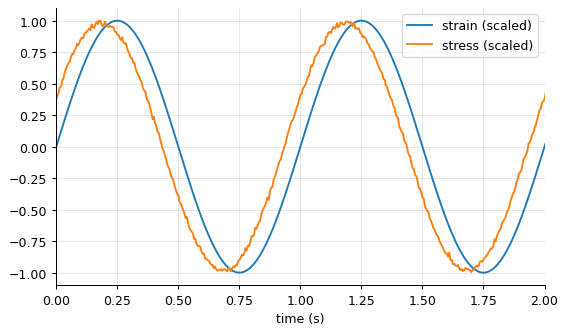

G' = 800.3 Pa, G'' = 349.9 Pa, phase angle 23.6 deg   (true 800, 350 Pa)


In [2]:
w = 2 * np.pi * 1.0                                        # 1 Hz
t = np.linspace(0, 3, 600, endpoint=False)
strain = 0.01 * np.sin(w * t)
stress = 0.01 * (800 * np.sin(w * t) + 350 * np.cos(w * t)) + np.random.default_rng(8).normal(0, 0.1, t.size)
r = oscillatory.moduli_from_waveforms(t, strain, stress, w)
plt.plot(t, strain / strain.max(), label="strain (scaled)"); plt.plot(t, stress / np.abs(stress).max(), label="stress (scaled)")
plt.xlim(0, 2); plt.xlabel("time (s)"); plt.legend(); plt.show()
print(f"G' = {r['Gp']:.1f} Pa, G'' = {r['Gpp']:.1f} Pa, phase angle {r['delta_deg']:.1f} deg   (true 800, 350 Pa)")

The stress leads the strain by the phase angle $\delta$ ($0°$ for an elastic solid, $90°$ for a viscous liquid);
$G' = |G^*|\cos\delta$ and $G'' = |G^*|\sin\delta$.

## Frequency sweep: a polymer melt

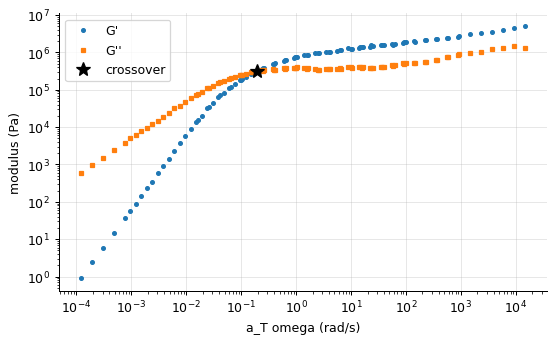

crossover at 0.194 rad/s -> characteristic relaxation time 1/omega_c = 5.16 s
terminal slopes (lowest decade): d ln G'/d ln w = 1.99 (theory 2), d ln G''/d ln w = 1.01 (theory 1)


In [3]:
melt = pd.read_csv(datasets.path("polystyrene_frequency_sweeps.csv"), comment="#")
curves = {T_C + 273.15: (g.omega_rad_s.to_numpy(), g[["G_storage_Pa", "G_loss_Pa"]].to_numpy()) for T_C, g in melt.groupby("temperature_C")}
mc = tts.master_curve(curves, 443.15)
wr = np.concatenate([mc["omega_reduced"][T_] for T_ in sorted(curves)])
Y = np.vstack([mc["y"][T_] for T_ in sorted(curves)])
order = np.argsort(wr)
wr, Gp, Gpp = wr[order], Y[order, 0], Y[order, 1]
cx = oscillatory.crossover(wr, Gp, Gpp)
plt.loglog(wr, Gp, "o", ms=3, label="G'"); plt.loglog(wr, Gpp, "s", ms=3, label="G''")
plt.loglog(*cx, "k*", ms=12, label="crossover")
plt.xlabel("a_T omega (rad/s)"); plt.ylabel("modulus (Pa)"); plt.legend(); plt.show()
low = wr < wr.min() * 10
print(f"crossover at {cx[0]:.3g} rad/s -> characteristic relaxation time 1/omega_c = {1/cx[0]:.3g} s")
print(f"terminal slopes (lowest decade): d ln G'/d ln w = {np.polyfit(np.log(wr[low]), np.log(Gp[low]), 1)[0]:.2f} (theory 2), "
      f"d ln G''/d ln w = {np.polyfit(np.log(wr[low]), np.log(Gpp[low]), 1)[0]:.2f} (theory 1)")

At low frequencies (long times) the melt flows: $G'' > G'$, approaching the terminal slopes 2 and 1. Above
the crossover, elasticity dominates. A higher molecular weight moves the crossover to lower frequencies.

## Amplitude sweep: where does the linear range end?
Before any frequency sweep, an amplitude sweep checks how large a strain the structure tolerates:

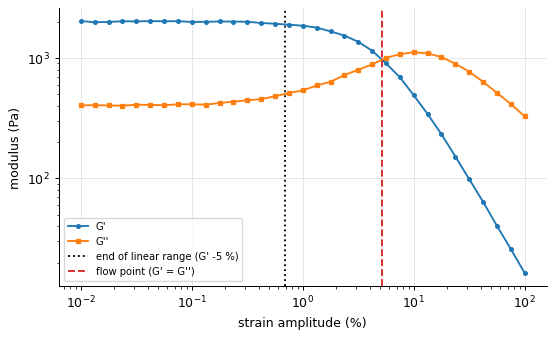

linear range up to 0.69 % strain (true 0.79 %); flow point at 5.2 % strain


In [4]:
cream = pd.read_csv(datasets.path("cream_amplitude_sweep.csv"), comment="#")
s, gp_c, gpp_c = cream.strain_amplitude.to_numpy(), cream.G_storage_Pa.to_numpy(), cream.G_loss_Pa.to_numpy()
lim = oscillatory.lve_limit(s, gp_c)
flow = oscillatory.crossover(s, gp_c, gpp_c)
plt.loglog(s * 100, gp_c, "o-", ms=3, label="G'"); plt.loglog(s * 100, gpp_c, "s-", ms=3, label="G''")
plt.axvline(lim * 100, color="k", ls=":", label="end of linear range (G' -5 %)")
plt.axvline(flow[0] * 100, color="C3", ls="--", label="flow point (G' = G'')")
plt.xlabel("strain amplitude (%)"); plt.ylabel("modulus (Pa)"); plt.legend(fontsize=8); plt.show()
print(f"linear range up to {lim*100:.2f} % strain (true {100*0.05*(1/0.95-1)**(1/1.6):.2f} %); flow point at {flow[0]*100:.1f} % strain")

Below the limit, moduli are independent of amplitude and characterise the undisturbed structure; frequency
sweeps must stay there. The estimate itself is approximate: a 5 % criterion applied to data with about 1 %
scatter and eight points per decade can only locate the limit roughly - here somewhat early - so stay well
below it in practice. Beyond the **flow point** ($G' = G''$) the cream's structure breaks down and it flows -
the oscillatory counterpart of a yield stress. The rise of $G''$ just before is typical of soft solids.

## Time sweep: when does a food gel set?
At the gel point a percolating network first spans the sample. Winter and Chambon showed that there
$\tan\delta$ is independent of frequency, so time sweeps at several frequencies cross at one instant:

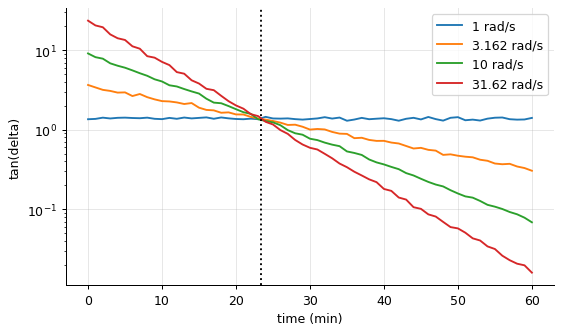

Winter-Chambon gel time 23.38 min (true 23.4); simple G' = G'' crossover at 10 rad/s: 26.9 min


In [5]:
gel = pd.read_csv(datasets.path("food_gel_time_sweep.csv"), comment="#")
piv = gel.assign(tan_delta=gel.G_loss_Pa / gel.G_storage_Pa).pivot(index="time_min", columns="omega_rad_s", values="tan_delta")
for w_ in piv.columns:
    plt.semilogy(piv.index, piv[w_], label=f"{w_:g} rad/s")
tg = oscillatory.gel_point(piv.index.to_numpy(), piv.to_numpy())
plt.axvline(tg, color="k", ls=":"); plt.xlabel("time (min)"); plt.ylabel("tan(delta)"); plt.legend(); plt.show()
single = gel[gel.omega_rad_s == 10.0]
cross_10 = oscillatory.crossover(single.time_min, single.G_loss_Pa, single.G_storage_Pa)
print(f"Winter-Chambon gel time {tg:.2f} min (true 23.4); simple G' = G'' crossover at 10 rad/s: {cross_10[0]:.1f} min")

The frequently used shortcut - the time at which $G'$ overtakes $G''$ at a single frequency - depends on the
chosen frequency and does not coincide with the gel point in general; the frequency-independent crossing
of $\tan\delta$ does.

## The Cox-Merz rule
For many polymer solutions and melts, the steady-shear viscosity at shear rate $\dot\gamma$ equals the magnitude
of the complex viscosity at $\omega = \dot\gamma$ - a practical shortcut when steady shear is difficult:

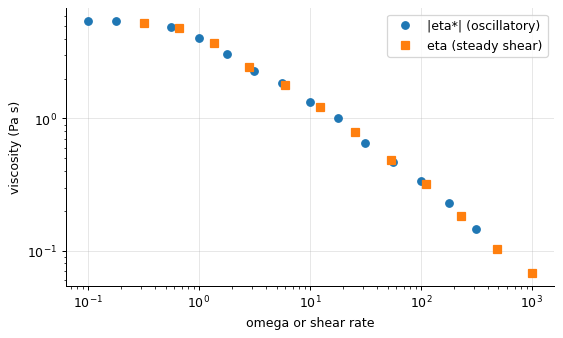

steady / complex viscosity over the common range: 0.98 to 1.06


In [6]:
sol = pd.read_csv(datasets.path("polymer_solution_cox_merz.csv"), comment="#")
osc, stdy = sol[sol.test == "oscillatory"], sol[sol.test == "steady"]
ratio = oscillatory.cox_merz_ratio(stdy.rate_or_frequency, stdy.viscosity_Pa_s, osc.rate_or_frequency, osc.viscosity_Pa_s)
plt.loglog(osc.rate_or_frequency, osc.viscosity_Pa_s, "o", label="|eta*| (oscillatory)")
plt.loglog(stdy.rate_or_frequency, stdy.viscosity_Pa_s, "s", label="eta (steady shear)")
plt.xlabel("omega or shear rate"); plt.ylabel("viscosity (Pa s)"); plt.legend(); plt.show()
print(f"steady / complex viscosity over the common range: {np.nanmin(ratio):.2f} to {np.nanmax(ratio):.2f}")

The rule holds well for this polymer solution. It generally fails for materials with a structure that
steady shear destroys but small oscillations do not - gels, emulsions like the cream above, suspensions,
yield-stress fluids - whose complex viscosity lies far above the steady viscosity.

## Inside the algorithm: moduli from waveforms by hand
Project the stress onto $\sin\omega t$ and $\cos\omega t$ over whole cycles (the first Fourier coefficient); for a
strain $\gamma_0\sin\omega t$ the in-phase part divided by $\gamma_0$ is $G'$, the quadrature part $G''$:

In [7]:
ns = t.size
in_phase = 2 / ns * np.sum(stress * np.sin(w * t))
quadrature = 2 / ns * np.sum(stress * np.cos(w * t))
print(f"by hand: G' = {in_phase / 0.01:.2f} Pa, G'' = {quadrature / 0.01:.2f} Pa;  library: {r['Gp']:.2f}, {r['Gpp']:.2f}")

by hand: G' = 800.26 Pa, G'' = 349.88 Pa;  library: 800.26, 349.88


## Exercises
1. Using only the 220 degC frequency sweep (unshifted), estimate the terminal slopes of G' and G''. Why are they closer to the theoretical values than at 150 degC?
2. Determine the gel time using only two frequencies (1 and 31.6 rad/s) instead of four. How robust is the Winter-Chambon estimate?
3. **Implement it yourself:** find the crossover of the melt's G' and G'' by hand: locate the sign change of $\ln G' - \ln G''$ and interpolate linearly in log-log coordinates; compare with `oscillatory.crossover`.